# Customer Segmentation using RFM and K-Means

## Project Overview

This project aims to segment customers based on their purchasing behavior using RFM analysis and clustering techniques.

The dataset contains transaction-level retail data. The first step is to transform these transactions into a customer-level RFM table.

The workflow consists of six required points:

1. Building a customer-level RFM feature table
2. Scaling the RFM features
3. Choosing the number of clusters using Elbow Method and Silhouette Score
4. Fitting K-Means using the selected number of clusters
5. Visualizing the clusters using PCA
6. Defining business-oriented customer personas based on cluster-level RFM averages

# Point 1 — RFM Feature Construction

The raw dataset contains transaction-level data, where each row represents a customer transaction.

The goal of this section is to transform the transaction-level data into a customer-level RFM table using Recency, Frequency, and Monetary.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv("../../../../01-ml-project/retail_transactions_segmentation.csv")

data = df.copy()

display(data.head())

,customer_id,transaction_date,amount,product_category
0,5206,2024-01-31,162.65,Fashion
1,5153,2024-07-03,389.85,Fashion
2,5102,2024-11-13,453.72,Home & Living
3,5073,2024-03-11,824.74,Electronics
4,5097,2024-12-28,181.74,Sports


## 2. Data Inspection

Before calculating the RFM features, we inspect the dataset structure, data types, missing values, and duplicate rows.

In [4]:
print("Dataset shape:", data.shape)

Dataset shape: (3663, 4)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3663 entries, 0 to 3662
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       3663 non-null   int64  
 1   transaction_date  3663 non-null   str    
 2   amount            3663 non-null   float64
 3   product_category  3663 non-null   str    
dtypes: float64(1), int64(1), str(2)
memory usage: 114.6 KB


In [6]:
df.describe()

,customer_id,amount
count,3663.000000,3663.000000
mean,5147.309036,513.028376
std,85.189230,305.332100
min,5001.000000,5.000000
25%,5073.000000,276.550000
50%,5142.000000,411.870000
75%,5223.000000,767.740000
max,5300.000000,1506.360000


In [7]:
df.columns

Index(['customer_id', 'transaction_date', 'amount', 'product_category'], dtype='str')

In [8]:
df.isnull().sum()

customer_id         0
transaction_date    0
amount              0
product_category    0
dtype: int64

In [9]:
df.isnull().sum().sum()

np.int64(0)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.dtypes

customer_id           int64
transaction_date        str
amount              float64
product_category        str
dtype: object

## 3. Date Conversion

The `transaction_date` column is converted to datetime format so that date calculations can be performed correctly when calculating Recency.

In [12]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

In [13]:
df["transaction_date"].dtype

dtype('<M8[us]')

In [14]:
df["transaction_date"].min()

Timestamp('2024-01-01 00:00:00')

In [15]:
df["transaction_date"].max()

Timestamp('2024-12-30 00:00:00')

## RFM Analysis

### Reference Date
We use the latest transaction date as the reference date for calculating Recency.

In [16]:
reference_date = df["transaction_date"].max()

print("Reference Date:", reference_date)

Reference Date: 2024-12-30 00:00:00


### Calculate Recency

Recency represents the number of days since each customer's last purchase.

In [17]:
last_purchase = df.groupby("customer_id")["transaction_date"].max()
recency = (reference_date - last_purchase).dt.days

recency_df = recency.reset_index(name="Recency")

display(recency_df.head())

,customer_id,Recency
0,5001,1
1,5002,22
2,5003,36
3,5004,4
4,5005,25


### Calculate Frequency

Frequency represents the number of transactions made by each customer.

In [18]:
frequency = df.groupby("customer_id").size()

frequency_df = frequency.reset_index(name="Frequency")

display(frequency_df.head())

,customer_id,Frequency
0,5001,16
1,5002,18
2,5003,3
3,5004,35
4,5005,16


### Calculate Monetary

Monetary represents the total amount spent by each customer.

In [19]:
monetary = df.groupby("customer_id")["amount"].sum()

monetary_df = monetary.reset_index(name="Monetary")

display(monetary_df.head())

,customer_id,Monetary
0,5001,5172.45
1,5002,6158.98
2,5003,654.12
3,5004,31050.88
4,5005,5700.91


### Combine RFM Metrics

Merge Recency, Frequency, and Monetary into a single RFM DataFrame.

In [20]:
rfm = recency_df.merge(frequency_df, on="customer_id")
rfm = rfm.merge(monetary_df, on="customer_id")

display(rfm.head())

,customer_id,Recency,Frequency,Monetary
0,5001,1,16,5172.45
1,5002,22,18,6158.98
2,5003,36,3,654.12
3,5004,4,35,31050.88
4,5005,25,16,5700.91


### Validate RFM Data

Check the shape, number of unique customers, and a sample of the RFM dataset.

In [21]:
print("RFM Shape:", rfm.shape)

RFM Shape: (300, 4)


In [22]:
print("Unique Customers:", rfm["customer_id"].nunique())

Unique Customers: 300


In [23]:
print("Duplicate Customer IDs:", rfm["customer_id"].duplicated().sum())

Duplicate Customer IDs: 0


In [24]:
display(rfm.head())

,customer_id,Recency,Frequency,Monetary
0,5001,1,16,5172.45
1,5002,22,18,6158.98
2,5003,36,3,654.12
3,5004,4,35,31050.88
4,5005,25,16,5700.91


# Scaling and Choosing the Number of Clusters

In this section, we prepare the RFM features for K-Means clustering and determine the most appropriate number of clusters (K).

The main steps are:

1. Select the RFM features.
2. Standardize the features using StandardScaler.
3. Test different values of K.
4. Use the Elbow Method to evaluate the clustering compactness.
5. Use the Silhouette Score to evaluate cluster separation.
6. Compare the results and select the most appropriate K.

## 1. Preparing the RFM Features

We use the three RFM features for customer segmentation:

- **Recency:** Number of days since the customer's last transaction.
- **Frequency:** Number of transactions made by the customer.
- **Monetary:** Total amount spent by the customer.

The `customer_id` column is not used as a clustering feature because it is only an identifier and does not represent customer behavior.

In [25]:
features = rfm[["Recency", "Frequency", "Monetary"]]

## 2. Feature Scaling

The RFM features have different numerical scales, especially the Monetary feature.

To prevent features with larger numerical values from dominating the K-Means distance calculations, we standardize the RFM features using `StandardScaler`.

After scaling, each feature has approximately:

- Mean = 0
- Standard deviation = 1

This makes the three RFM features comparable during clustering.

In [26]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(features)

In [27]:
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"]
)

rfm_scaled.head()

,Recency,Frequency,Monetary
0,-0.772792,0.356692,-0.113196
1,-0.464634,0.544920,-0.010898
2,-0.259195,-0.866790,-0.581723
3,-0.728770,2.144859,2.570262
4,-0.420611,0.356692,-0.058397


### Choosing the Number of Clusters

Based on the Elbow Method, the reduction in inertia becomes less significant after K=3, indicating an elbow around K=3.

The Silhouette Score also supports this choice, as K=3 provides a strong separation between the clusters compared with nearby values of K.

Therefore, K=3 was selected as the final number of clusters.

## 3. Testing Different Values of K

K-Means requires us to specify the number of clusters in advance.

Since the optimal number of clusters is not known beforehand, we test multiple values of K, from 2 to 10.

For each value of K, we calculate:

- **Inertia:** Used for the Elbow Method.
- **Silhouette Score:** Used to evaluate how well the clusters are separated.

In [30]:
inertia = []
silhouette_scores = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(rfm_scaled)
    
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(rfm_scaled, labels)
    )

## 4. Elbow Method

The Elbow Method helps us determine a suitable number of clusters by examining the **inertia** for different values of K.

Inertia measures the total squared distance between each data point and the centroid of its assigned cluster.

As K increases, inertia decreases. We look for an "elbow" point where adding more clusters results in a smaller improvement.

This point can indicate a suitable value of K.

### Elbow Method Interpretation

The plot above shows how the inertia changes as the number of clusters increases.

We look for the point where the decrease in inertia becomes less significant. This point represents the potential elbow and provides evidence for selecting the number of clusters.

The Elbow Method is considered together with the Silhouette Score before making the final decision.

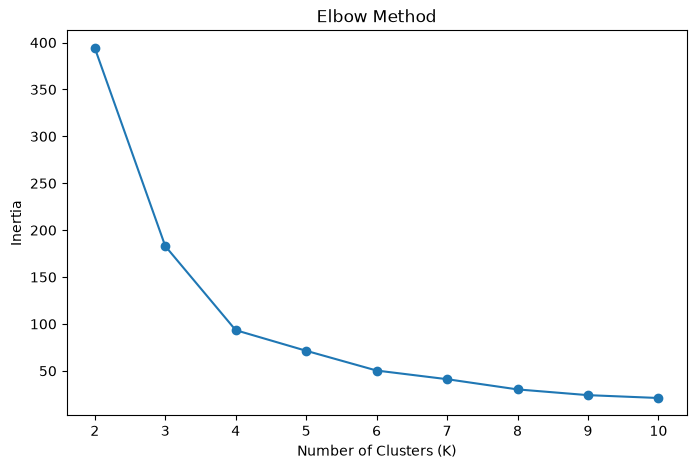

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.xticks(k_values)
plt.show()

## 5. Silhouette Score

The Silhouette Score evaluates how well each customer fits within its assigned cluster compared with other clusters.

The score ranges from -1 to 1:

- A higher score indicates better-defined and more separated clusters.
- A score close to 0 indicates overlapping clusters.
- A negative score may indicate that some observations are assigned to inappropriate clusters.

We calculate the Silhouette Score for each tested value of K and compare the results.

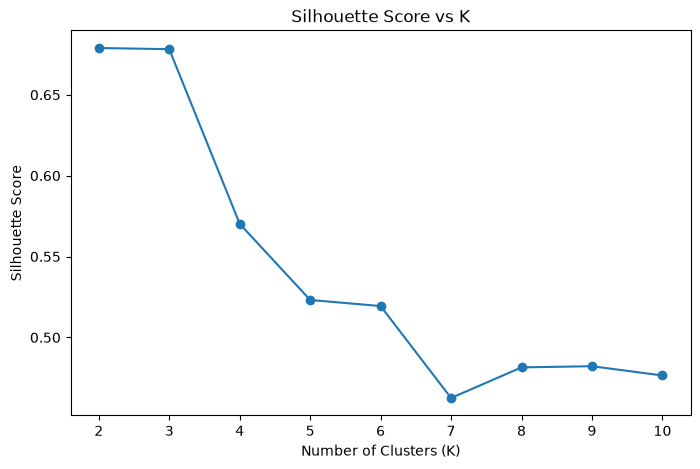

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, silhouette_scores, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")

plt.xticks(k_values)
plt.show()

## 6. Comparing K Values

To make the selection of K more systematic, we compare the Inertia and Silhouette Score for all tested values of K.

The Elbow Method focuses on the reduction in inertia, while the Silhouette Score focuses on the quality of cluster separation.

Using both measures provides stronger evidence than relying on only one metric.

In [33]:
results = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertia,
    "Silhouette Score": silhouette_scores
})

results

,K,Inertia,Silhouette Score
0,2,394.208028,0.678910
1,3,183.032138,0.678170
2,4,93.388049,0.570227
3,5,71.407066,0.523155
4,6,50.343627,0.519382
5,7,41.125688,0.462554
6,8,30.223591,0.481482
7,9,24.119083,0.482195
8,10,21.074266,0.476483


## 7. Selecting the Optimal Number of Clusters

Based on the Elbow Method and Silhouette Score, we compare the tested values of K and select the most appropriate number of clusters.

The final choice should consider:

- The location of the elbow in the inertia curve.
- The Silhouette Score and how well the clusters are separated.
- Whether increasing K provides a meaningful improvement over smaller values.

We select the value of K that provides a good balance between cluster compactness and separation.

### Final Decision

Based on the results, **K = X** was selected as the final number of clusters.

The Elbow Method indicates that the improvement in inertia becomes less significant after K = X. The Silhouette Score also provides supporting evidence for this choice compared with the nearby K values.

Therefore, K = X provides a reasonable balance between reducing within-cluster variation and maintaining well-separated customer groups.